In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv('df_finale_pulito.csv')
df['codice_comune'] = df['codice_comune'].astype(str).str.zfill(6)
df

# carico il dataset pulito salvato nel notebook di preparazione. il csv non
# conserva il tipo delle colonne, quindi il codice_comune (che avevo salvato
# come stringa a 6 cifre) viene riletto come intero e perde gli zeri davanti
# (001001 diventa 1001). lo riporto subito a stringa con zfill, così resta
# coerente e posso riusarlo come chiave senza problemi

,codice_comune,anno,feriti,morti,incidenti,comune,sigla,superficie_kmq,popolazione,incidenti_per_kmq,incidenti_per_1000_abitanti
0,001001,2001,10,0,5,Agliè,TO,13.1462,2557,0.38,1.96
1,001001,2002,10,0,5,Agliè,TO,13.1462,2538,0.38,1.97
2,001001,2003,7,0,4,Agliè,TO,13.1462,2588,0.30,1.55
3,001001,2004,13,0,9,Agliè,TO,13.1462,2679,0.68,3.36
4,001001,2005,2,0,2,Agliè,TO,13.1462,2674,0.15,0.75
...,...,...,...,...,...,...,...,...,...,...,...
184556,111107,2019,5,0,5,Villaspeciosa,SU,27.1937,2605,0.18,1.92
184557,111107,2020,3,0,2,Villaspeciosa,SU,27.1937,2549,0.07,0.78
184558,111107,2021,7,0,5,Villaspeciosa,SU,27.1943,2536,0.18,1.97
184559,111107,2022,1,0,1,Villaspeciosa,SU,27.1943,2575,0.04,0.39


In [ ]:
df.info()
df.describe()

# lancio .info() e .describe() per controllare che sia tutto congruente con quanto fatto prima.
# anche qui vedo una deviazione standard molto più alta della media per quanto riguarda feriti e n° di incidenti,
# segno che il pattern di dati è rimasto intatto, come già visto nell'altro notebook,
# sono solo più puliti e meglio rappresentati. ci tengo a ricordare che ho escluso il 2024
# perchè aveva il 20% di comuni in meno rispetto al 2023 e questo mi avrebbe potuto portare
# ad un errata rappresentazione dei dati

<class 'pandas.DataFrame'>
RangeIndex: 184561 entries, 0 to 184560
Data columns (total 11 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   codice_comune                184561 non-null  str    
 1   anno                         184561 non-null  int64  
 2   feriti                       184561 non-null  int64  
 3   morti                        184561 non-null  int64  
 4   incidenti                    184561 non-null  int64  
 5   comune                       184538 non-null  str    
 6   sigla                        182445 non-null  str    
 7   superficie_kmq               184561 non-null  float64
 8   popolazione                  184561 non-null  int64  
 9   incidenti_per_kmq            184561 non-null  float64
 10  incidenti_per_1000_abitanti  184561 non-null  float64
dtypes: float64(3), int64(5), str(3)
memory usage: 15.5 MB


,anno,feriti,morti,incidenti,superficie_kmq,popolazione,incidenti_per_kmq,incidenti_per_1000_abitanti
count,184561.000000,184561.000000,184561.000000,184561.000000,184561.000000,1.845610e+05,184561.000000,184561.000000
mean,2011.938920,35.034541,0.535238,24.921787,37.563161,7.366364e+03,0.709254,1.980402
std,6.625345,340.079145,2.804796,258.693771,50.233277,4.083294e+04,2.065203,2.366082
min,2001.000000,0.000000,0.000000,0.000000,0.120600,2.800000e+01,0.000000,0.000000
25%,2006.000000,1.000000,0.000000,1.000000,11.292500,1.017000e+03,0.020000,0.390000
50%,2012.000000,5.000000,0.000000,3.000000,22.018800,2.413000e+03,0.150000,1.480000
75%,2018.000000,18.000000,0.000000,12.000000,43.648500,6.054000e+03,0.560000,2.790000
max,2023.000000,30254.000000,363.000000,23135.000000,1288.187500,2.820219e+06,99.220000,175.310000


# Distribuzione degli incidenti tra i comuni

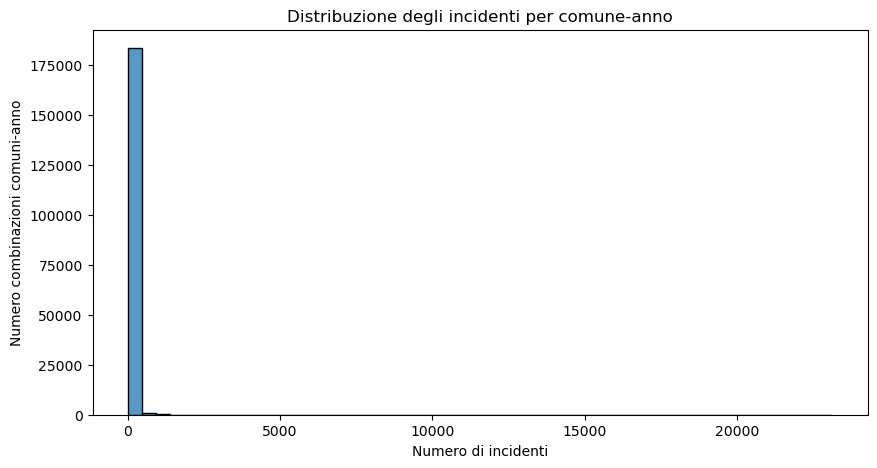

In [13]:
plt.figure(figsize=(10, 5))
sns.histplot(df['incidenti'], bins=50)
plt.title('Distribuzione degli incidenti per comune-anno')
plt.xlabel('Numero di incidenti')
plt.ylabel('Numero combinazioni comuni-anno')
plt.show()

# faccio l'istogramma degli incidenti, ma viene illeggibile, si vede solo una
# barra altissima schiacciata a sinistra e il resto vuoto. all'inizio non
# capivo perché, poi mi sono ricordato degli outlier visti nell'altro notebook,
# tipo Roma Capitale con oltre 23000 incidenti. sono proprio loro che con
# numeri così enormi allungano l'asse fino a 23000 e schiacciano tutti gli
# altri comuni in un'unica barra. quindi il grafico normale non va bene per
# questi dati così sbilanciati

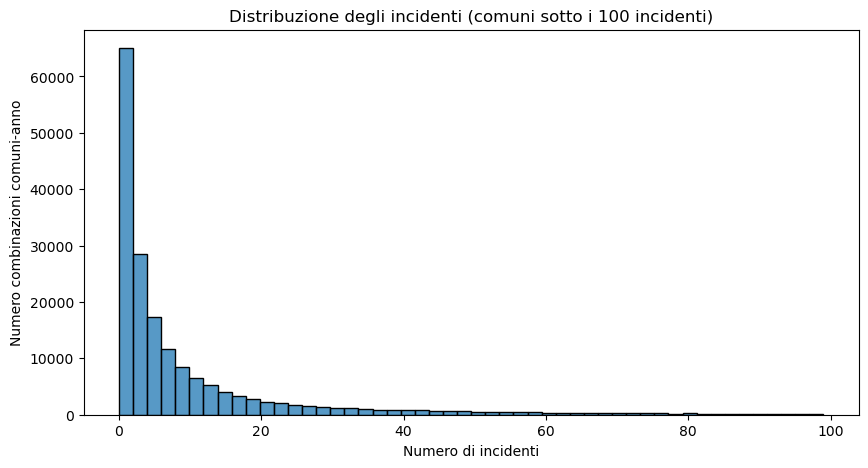

In [14]:
plt.figure(figsize=(10, 5))
sns.histplot(df[df['incidenti'] < 100]['incidenti'], bins=50)
plt.title('Distribuzione degli incidenti (comuni sotto i 100 incidenti)')
plt.xlabel('Numero di incidenti')
plt.ylabel('Numero combinazioni comuni-anno')
plt.show()

# per leggere meglio escludo i pochi grandi centri (sopra i 100 incidenti) e metto nel
# grafico solo il grosso dei record. così vedo bene come si distribuisce la
# maggioranza, infatti si veodno tantissime righe comune-anno con pochissimi incidenti e la curva che cala
# in fretta. gli outlier ovviamente non li ho cancellati dai dati, li ho solo tolti da
# questo grafico per renderlo leggibile

# Andamento degli incidenti nel tempo (2001-2023)

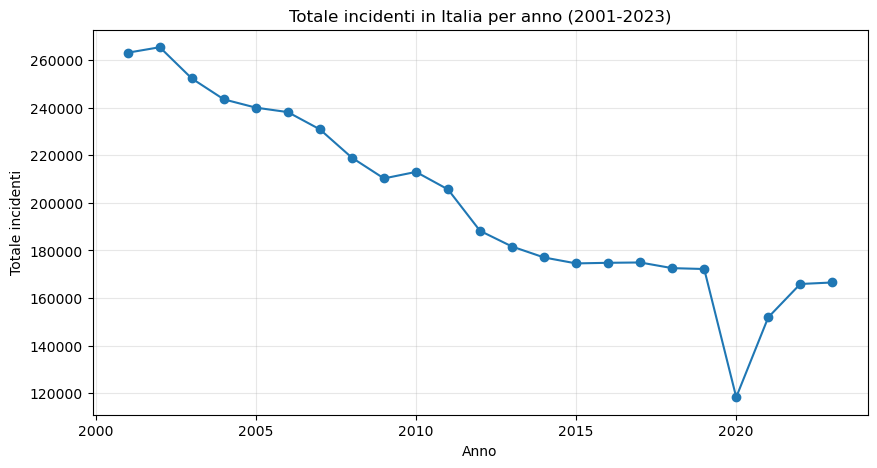

In [ ]:
incidenti_per_anno = df.groupby('anno')['incidenti'].sum()
incidenti_per_anno.plot(marker='o', figsize=(10, 5))

plt.title('Totale incidenti in Italia per anno (2001-2023)')
plt.xlabel('Anno')
plt.ylabel('Totale incidenti')
plt.grid(True, alpha=0.3)
plt.show()

# raggruppo per anno e sommo gli incidenti di tutti i comuni, ottenendo il
# totale nazionale anno per anno. poi con .plot() faccio direttamente il grafico
# a linea, pandas è intelligente e mette da solo gli anni sull'asse orizzontale e i totali su
# quello verticale. marker='o' aggiunge un pallino su ogni anno per leggere
# meglio i punti

Il totale degli incidenti in Italia cala in modo abbastanza costante dal 2001 al 2019, probabilmente grazie a strade e auto più sicure e a controlli più severi negli anni. nel 2020 c'è un crollo evidente, fino a circa 118.000 incidenti: è quasi sicuramente l'effetto del lockdown per il Covid, con le strade molto più vuote e quindi molti meno incidenti, dal 2021 il numero risale, ma per fortuna senza tornare ai livelli di prima della pandemia

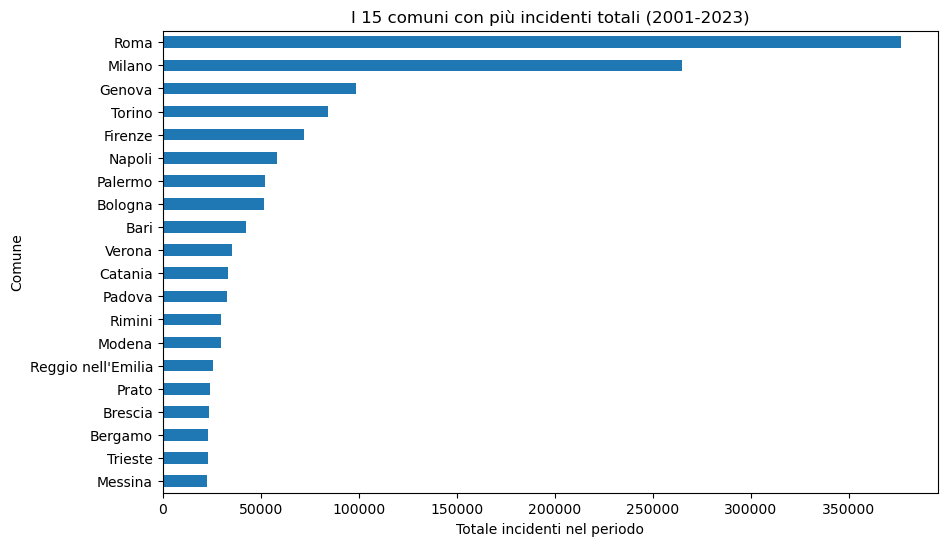

In [ ]:
top_comuni = df.groupby('comune')['incidenti'].sum().sort_values(ascending=False).head(20)

plt.figure(figsize=(10, 6))
top_comuni.sort_values().plot(kind='barh')
plt.title('I 20 comuni con più incidenti totali (2001-2023)')
plt.xlabel('Totale incidenti nel periodo')
plt.ylabel('Comune')
plt.show()

# voglio sapere quanti e quali sono i comuni con più incidenti.
# raggruppo per comune e sommo gli incidenti dei 23 anni, poi prendo i 20 con
# il totale più alto e li metto in un grafico a barre orizzontali.
# mi aspetto le grandi città in cima (Roma, Milano...), perché più
# popolazione e più traffico significano più incidenti in valore assoluto

# Verifica

Dal grafico qui sopra vedo che i comuni con più incidenti in assoluto sono tutte grandi città, Roma e Milano staccano nettamente, seguite da Genova, Torino, Firenze, Napoli e altri capoluoghi. Più popolazione e più traffico significano più incidenti in valore assoluto, ovviamente.

La domanda che mi sorge spontanea è: "se le grandi città hanno così tanti incidenti, magari qualcun altro avrà già pensato a investirci prima di noi?". Avendo più popolazione e più risorse, è lecito pensare che siano già presenti aziende che lavorano nel nostro stesso settore.

Questo è sostenuto dal modo in cui sono strutturati gli investimenti pubblici, che seguono delle fasce di popolazione. Da un lato i comuni piccoli sotto i 5.000 abitanti hanno un fondo dedicato per la sicurezza stradale (art. 19 D.L. 104/2023). Dall'altro, le grandi città attingono a canali propri come i fondi PNRR per la rigenerazione urbana, rivolti ai comuni sopra i 15.000 abitanti, ai comuni sopra i 60.000 (programma PINQUA) e alle 14 città metropolitane (Piani Urbani Integrati). Quindi grandi e piccoli centri hanno strade di finanziamento separate.

Va però detto che questi fondi sono recenti (il fondo piccoli comuni è del 2023, il PNRR del 2021 in poi) e non c'entrano con l'andamento storico degli incidenti che ho analizzato dal 2001. Li cito non per spiegare il passato, ma perché fotografano com'è strutturato il mercato oggi, e la decisione di dove investire la prenderei adesso, non vent'anni fa. Resta comunque un'ipotesi di mercato, non una cosa che posso dimostrare con i miei dati ISTAT (che mi dicono quanti incidenti ci sono, non chi ci sta già investendo).

La domanda allora è: ha senso aprire dove la concorrenza è probabilmente già stabilita, o è meglio concentrarsi su comuni più piccoli ma comunque pericolosi, dove magari c'è meno presidio?

Fonti:
- Fondo investimenti stradali nei piccoli Comuni (art. 19 D.L. 104/2023): https://trasparenza.mit.gov.it/archivio28_provvedimenti-amministrativi_0_220080_726_1.html
- Investimenti PNRR per le città metropolitane: https://lentepubblica.it/buone-pratiche/pnrr-rigenerazione-urbana-investimenti-citta-metropolitane-2024/

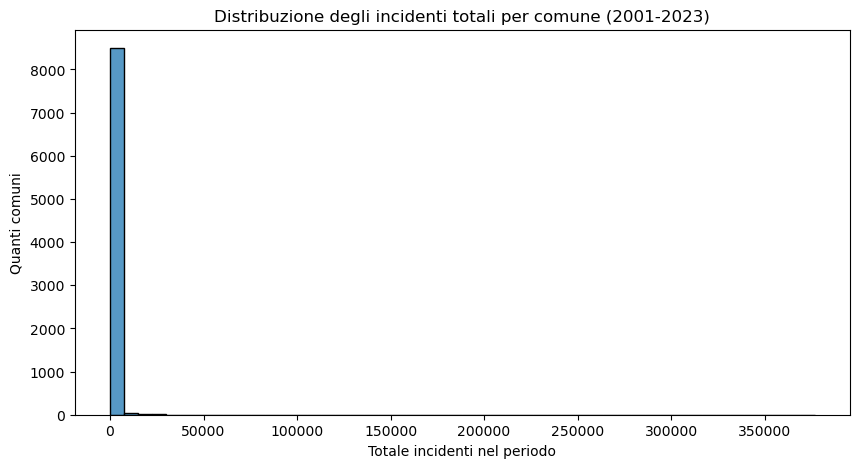

In [ ]:
incidenti_per_comune = df.groupby('codice_comune')['incidenti'].sum()

plt.figure(figsize=(10, 5))
sns.histplot(incidenti_per_comune, bins=50)
plt.title('Distribuzione degli incidenti totali per comune (2001-2023)')
plt.xlabel('Totale incidenti nel periodo')
plt.ylabel('Quanti comuni')
plt.show()

# sommo gli incidenti di tutti gli anni per ogni comune, poi faccio l'istogramma
# di questi totali. come prima, mi aspetto una forma molto sbilanciata dove ci sono tanti
# comuni con totali bassi e pochi grandi centri con totali enormi. guardo dove
# la maggioranza si concentra per scegliere una soglia con cui escludere le
# grandi città nel grafico dopo